In [ ]:
from modules.preprocessing import create_features, get_data, get_preprocessor, split_data
import pandas as pd
import numpy as np

features, target = get_data()
preprocessor = get_preprocessor(features, target)
features = create_features(features)

X_train, X_valid, X_test, y_train, y_valid, y_test = split_data(features, target)
X_train = preprocessor.fit_transform(X_train)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)

X_train = pd.DataFrame(np.array(X_train), columns=preprocessor.get_feature_names_out())
X_valid = pd.DataFrame(np.array(X_valid), columns=preprocessor.get_feature_names_out())
X_test = pd.DataFrame(np.array(X_test), columns=preprocessor.get_feature_names_out())

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

model = LGBMClassifier(
    random_state=42,
    force_col_wise=True,
    max_depth=8,
    num_leaves=34,
    n_estimators=120,
    learning_rate=0.01,
    # is_unbalance=True,
    # class_weight='balanced',
    scale_pos_weight=5,
    colsample_bytree=0.8,
)

model.fit(X_train, y_train)
valid_pred = model.predict(X_valid)
valid_pred_proba = model.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, valid_pred_proba)


accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)


print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, ROC AUC: {roc_auc:.4f}")

[LightGBM] [Info] Number of positive: 1154, number of negative: 4471
[LightGBM] [Info] Total Bins 1377
[LightGBM] [Info] Number of data points in the train set: 5625, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205156 -> initscore=-1.354378
[LightGBM] [Info] Start training from score -1.354378
Validation 성능 - Accuracy: 0.8267, F1 Score: 0.6234, Recall: 0.6969, Precision: 0.5639, ROC AUC: 0.8615


Validation 성능 - Accuracy: 0.7957, F1 Score: 0.6064, Recall: 0.7642, Precision: 0.5026 160

In [23]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(y_valid, valid_pred)
f1 = f1_score(y_valid, valid_pred)
recall = recall_score(y_valid, valid_pred)
precision = precision_score(y_valid, valid_pred)

print(f"Validation 성능 - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}")

Validation 성능 - Accuracy: 0.7973, F1 Score: 0.6082, Recall: 0.7642, Precision: 0.5051


/Users/tera/Desktop/workspace/skn_21/project/project_02_team_repo/ne_eun/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:379: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


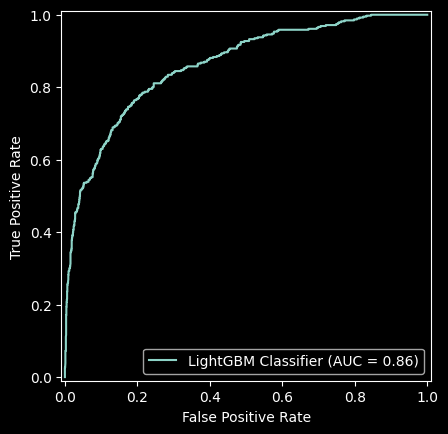

In [24]:

from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score

rfc_roc = roc_auc_score(y_valid, valid_pred_proba)
fpr, recall, thresh = roc_curve(y_valid, valid_pred_proba)
disp_roc_rfc = RocCurveDisplay(
    fpr=fpr, tpr=recall,
    roc_auc=rfc_roc,
    estimator_name='LightGBM Classifier'
)
disp_roc_rfc.plot()


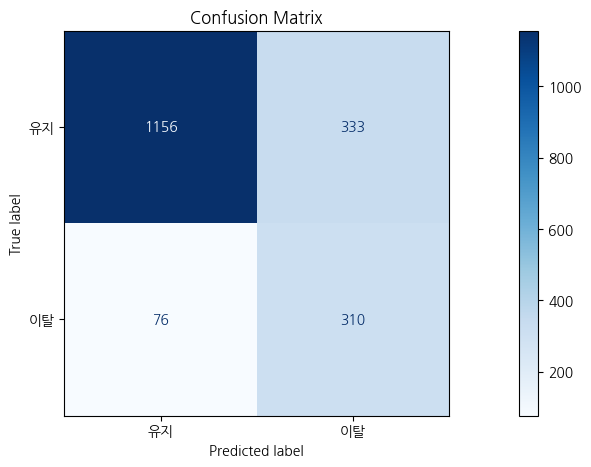

In [141]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots( figsize=(18, 5))

cm = confusion_matrix(y_valid, valid_pred)
ConfusionMatrixDisplay(cm, display_labels=['유지', '이탈']).plot(ax=axes, cmap='Blues')
axes.set_title('Confusion Matrix')

plt.show()

In [24]:
# 오버샘플링을 해봤지만 성능에 큰 향상이 없었음.
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)